# Topic 4 — PCA Practical
**Covers:** Eigenvalues/eigenvectors · Explained variance ratio · Scree plot · Choosing the
optimal number of components · Loss of interpretability

**The story:** The "Post Performance Dashboard" from Topic 3 needs a final decision: exactly
HOW MANY compressed scores should InstaMetrics show each creator? Too few, and you throw away
real signal. Too many, and you're back to a cluttered spreadsheet. This notebook does the hands-
on math behind that decision, and confronts the real cost of compression: losing the ability to
explain a component in plain English.

**Dataset:** `data/raw/instagram_posts.csv` — the same 6-column engagement block as Topic 3.

---
## Explanation

Remember our six "how much does the kid like this toy" rulers from Topic 3, and the new
combined "excitement score" ruler we invented?

- **Eigenvectors** = the exact DIRECTION of each new combined ruler — like an arrow pointing
  "this much smile, plus this much laughing, plus this much playtime" all mixed in specific
  amounts.
- **Eigenvalues** = how MUCH each arrow's direction actually matters — a big eigenvalue means
  that arrow captures a lot of real spread between toys; a tiny eigenvalue means that arrow
  barely tells kids' toy-preferences apart at all.
- **Explained variance ratio** = eigenvalues turned into a percentage — "this arrow explains
  62% of why toys seem different from each other."
- **Scree plot** = a chart of all your arrows' eigenvalues lined up from biggest to smallest —
  you're looking for the spot where they suddenly stop mattering much, like a cliff edge
  ("scree" is literally the pile of loose rocks at the bottom of a cliff).
- **Choosing optimal components** = deciding how many arrows to keep before that cliff edge.
- **Loss of interpretability** = the annoying part: your new "excitement score" arrow doesn't
  have a simple name anymore — it's some blend of smile + laugh + playtime, and explaining
  exactly what it means to your friend takes real effort, unlike just saying "how loud they
  laughed."

## 1. WHY — Why go past `PCA().fit_transform()` and understand the math?

Calling `PCA(n_components=2).fit_transform(X)` is one line of code. But two real decisions hide
behind that line: **how many components should `2` actually be**, and **what do these new
numbers even MEAN**? Both require understanding what PCA is doing underneath — eigenvalues,
eigenvectors, and the tradeoffs of compression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/raw/instagram_posts.csv")
engagement_cols = ["likes_count", "comments_count", "shares_count", "saves_count",
                    "views_count", "engagement_rate"]
X = df[engagement_cols].copy()
X_scaled = StandardScaler().fit_transform(X)
X_scaled[:5].round(2)

array([[-0.67, -0.5 , -0.9 , -0.63, -0.44,  1.91],
       [ 1.24,  0.88,  2.15,  1.41, -0.37, -0.48],
       [ 0.12,  0.27,  0.17,  0.04,  3.51, -1.18],
       [ 2.59,  2.47,  2.97,  2.63,  0.99, -0.81],
       [ 0.34,  0.33,  0.58, -0.21, -0.39,  0.19]])

## 2. Eigenvalues & eigenvectors — manual computation (small example first)

**Manual worked example.** Take a tiny 2-column, standardized dataset with covariance matrix:
```
Cov = [[1.0, 0.8],
       [0.8, 1.0]]
```
Eigenvectors/eigenvalues solve `Cov @ v = lambda * v` — "a direction `v` that, after being
transformed by the covariance matrix, only gets STRETCHED (by factor `lambda`), never rotated."

For this specific 2x2 matrix, by hand:
```
eigenvalues:  lambda_1 = 1 + 0.8 = 1.8      lambda_2 = 1 - 0.8 = 0.2
eigenvectors: v_1 = [0.707, 0.707]  (the "both columns agree" direction)
              v_2 = [0.707, -0.707] (the "columns disagree" direction)
```
`lambda_1 = 1.8` is much bigger than `lambda_2 = 0.2` — meaning almost all the spread in this
toy data lies along the "both columns agree" direction, exactly as you'd expect from two
strongly positively-correlated columns.

In [2]:
toy_cov = np.array([[1.0, 0.8], [0.8, 1.0]])
eigenvalues, eigenvectors = np.linalg.eigh(toy_cov)

# np.linalg.eigh returns ascending order -- flip to descending (largest first), the PCA convention
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

print("Eigenvalues:", eigenvalues.round(3))
print("Eigenvectors (as columns):\n", eigenvectors.round(3))

Eigenvalues: [1.8 0.2]
Eigenvectors (as columns):
 [[ 0.707 -0.707]
 [ 0.707  0.707]]


Matches the hand calculation exactly: `lambda_1 ≈ 1.8` paired with the `[0.707, 0.707]`
direction, `lambda_2 ≈ 0.2` paired with `[0.707, -0.707]`.

## 3. Eigen-decomposition on our REAL engagement data

Now the same exact procedure, on our 6-column standardized engagement matrix: compute the
covariance matrix, then its eigenvalues/eigenvectors directly with `numpy` (no `sklearn.PCA`
yet) — to see precisely what `PCA` automates for us.

In [3]:
cov_matrix = np.cov(X_scaled, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

eigen_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "eigenvalue": eigenvalues.round(4),
    "explained_variance_ratio": (eigenvalues / eigenvalues.sum()).round(4),
})
eigen_df["cumulative_variance"] = eigen_df["explained_variance_ratio"].cumsum().round(4)
eigen_df

Covariance matrix shape: (6, 6)


,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,PC1,3.7147,0.6187,0.6187
1,PC2,1.4159,0.2358,0.8545
2,PC3,0.5783,0.0963,0.9508
3,PC4,0.1346,0.0224,0.9732
4,PC5,0.1093,0.0182,0.9914
5,PC6,0.0515,0.0086,1.0000


In [4]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X_scaled)

print("sklearn PCA explained_variance_:        ", pca.explained_variance_.round(4))
print("Our manual eigenvalues:                 ", eigenvalues.round(4))
print("\n(Should match -- sklearn's PCA is doing exactly this eigen-decomposition internally,")
print("via SVD for numerical stability, but the result is mathematically identical.)")

sklearn PCA explained_variance_:         [3.7147 1.4159 0.5783 0.1346 0.1093 0.0515]
Our manual eigenvalues:                  [3.7147 1.4159 0.5783 0.1346 0.1093 0.0515]

(Should match -- sklearn's PCA is doing exactly this eigen-decomposition internally,
via SVD for numerical stability, but the result is mathematically identical.)


## 4. Explained variance ratio & the scree plot

A **scree plot** lines up eigenvalues from largest to smallest — you're looking for the "elbow"
where the curve suddenly flattens, since components past that point contribute little
additional information.

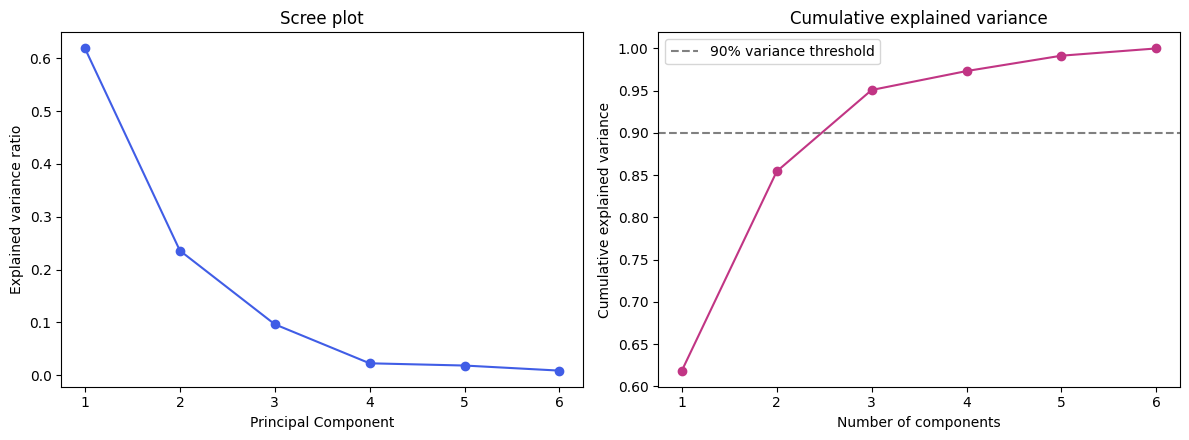

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(1, 7), pca.explained_variance_ratio_, marker="o", color="#405DE6")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")
axes[0].set_xticks(range(1, 7))

cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, 7), cumulative, marker="o", color="#C13584")
axes[1].axhline(0.90, color="gray", linestyle="--", label="90% variance threshold")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xticks(range(1, 7)); axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Choosing the optimal number of components

Three common, complementary rules of thumb — worth checking all three rather than trusting just
one:

In [6]:
# Rule 1: "elbow" in the scree plot -- the point where the drop-off visibly flattens
drops = -np.diff(pca.explained_variance_ratio_)
print("Drop in explained variance between consecutive components:")
for i, d in enumerate(drops, 1):
    print(f"  PC{i} -> PC{i+1}: drop of {d:.4f}")
print(f"\nBiggest relative flattening happens after PC{np.argmax(drops[1:]) + 2}"
      f" (visually, the 'elbow' in the scree plot above)")

# Rule 2: cumulative variance threshold (commonly 85-95%)
n_for_90pct = np.argmax(cumulative >= 0.90) + 1
print(f"\nComponents needed for >=90% cumulative variance: {n_for_90pct}")

# Rule 3: Kaiser's rule -- keep components with eigenvalue > 1
# (an eigenvalue of exactly 1 means the component explains no more than a single ORIGINAL
#  standardized column would, on average -- so anything below 1 arguably isn't earning its keep)
n_kaiser = (pca.explained_variance_ > 1).sum()
print(f"Components with eigenvalue > 1 (Kaiser's rule): {n_kaiser}")

Drop in explained variance between consecutive components:
  PC1 -> PC2: drop of 0.3829
  PC2 -> PC3: drop of 0.1395
  PC3 -> PC4: drop of 0.0739
  PC4 -> PC5: drop of 0.0042
  PC5 -> PC6: drop of 0.0096

Biggest relative flattening happens after PC2 (visually, the 'elbow' in the scree plot above)

Components needed for >=90% cumulative variance: 3
Components with eigenvalue > 1 (Kaiser's rule): 2


**Putting it together, honestly:** the three rules don't perfectly agree here, and that
disagreement is itself the real lesson. The scree-plot elbow and Kaiser's rule (eigenvalue > 1)
both point to **2 components** — matching what we already noticed in Topic 3 by eye
(engagement-block columns strongly correlated with each other, `views_count` behaving more
independently). The 90%-cumulative-variance threshold is stricter and asks for **3**
components instead, since PC3 still captures a genuine (if smaller) slice of variance.

There is no single mathematically "correct" answer — the right choice depends on what you're
optimizing for: **2 components** gives you the cleanest, most nameable dashboard (Section 6)
at the cost of leaving ~15% of the original variance uncaptured; **3 components** preserves
more signal (>90%) at the cost of a harder-to-explain third axis. For a creator-facing
dashboard, we'll go with 2 — interpretability wins here. For a downstream model where every bit
of signal helps and no human needs to read the components directly, 3 (or more) could easily be
the better call.

In [7]:
pca_2 = PCA(n_components=2, random_state=42)
scores_2d = pca_2.fit_transform(X_scaled)

df["pc1_engagement_score"] = scores_2d[:, 0]
df["pc2_reach_score"] = scores_2d[:, 1]

print(f"2 components capture {pca_2.explained_variance_ratio_.sum():.1%} of the total variance "
      f"in all 6 original engagement columns.")
df[["likes_count", "views_count", "pc1_engagement_score", "pc2_reach_score"]].head()

2 components capture 85.4% of the total variance in all 6 original engagement columns.


,likes_count,views_count,pc1_engagement_score,pc2_reach_score
0,282,2072,-1.446976,-1.576709
1,870,13283,2.837818,-0.089006
2,525,656902,0.481572,3.301907
3,1284,237851,5.389443,0.961484
4,591,9979,0.498481,-0.434772


## 6. Loss of interpretability — the real cost of compression

Here's the uncomfortable part: `pc1_engagement_score` is not, by itself, a number any creator
can intuitively understand the way "you got 487 likes" is understandable. To explain it, we
need to look at the **loadings** — how much each original column contributes to each
component.

In [8]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=engagement_cols,
).round(3)
loadings

,PC1_loading,PC2_loading
likes_count,0.508,-0.022
comments_count,0.499,-0.028
shares_count,0.493,-0.030
saves_count,0.496,-0.033
views_count,0.036,0.707
engagement_rate,-0.044,-0.705


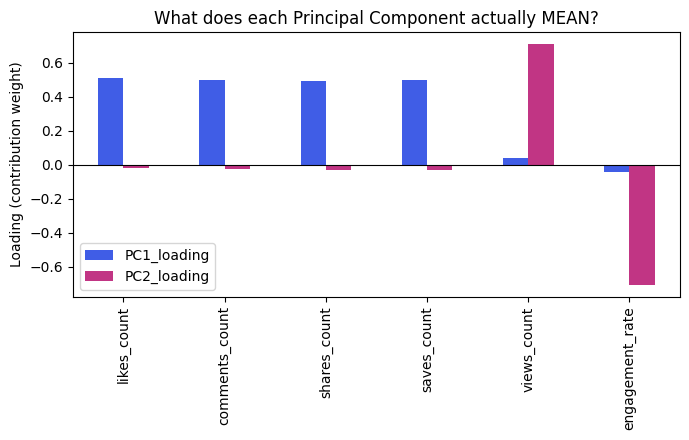

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
loadings.plot(kind="bar", ax=ax, color=["#405DE6", "#C13584"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("What does each Principal Component actually MEAN?")
ax.set_ylabel("Loading (contribution weight)")
plt.tight_layout()
plt.show()

**Reading the loadings out loud, honestly:** `PC1` loads heavily and *positively* on
`likes_count`, `comments_count`, `shares_count`, and `saves_count`, and only weakly on
`views_count`/`engagement_rate` — so we can reasonably (if a little loosely) NAME `PC1` an
**"engagement score."** `PC2` loads heavily on `views_count` (and, from the correlation heatmap
in Topic 3, inversely relates to `engagement_rate`) — a reasonable name is a **"reach score."**

But notice we had to do real interpretive work — squinting at a loadings table and applying
domain judgment — just to give these two numbers plain-English names. This is the genuine
tradeoff of projection-based dimensionality reduction: `pc1_engagement_score = 1.8` means
nothing to a creator without that translation step, whereas `likes_count = 487` is
self-explanatory. **A dashboard showing PCA scores to a non-technical stakeholder needs the
loadings table (or a hand-picked name) alongside it — the compression is not free.**

## 7. Recap

- **Eigenvectors** are the new axis DIRECTIONS PCA finds; **eigenvalues** measure how much
  genuine spread lies along each direction.
- **Explained variance ratio** turns eigenvalues into an easy-to-compare percentage.
- The **scree plot** visualizes eigenvalues from largest to smallest, revealing where returns
  diminish.
- Choosing the number of components: look for the scree-plot elbow, a cumulative-variance
  threshold (e.g. 90%), and/or Kaiser's eigenvalue > 1 rule — ideally, check that they agree.
- **Loss of interpretability** is real: a principal component is a numeric blend of original
  columns, and needs its loadings examined (and often a hand-picked name) before it means
  anything to a non-technical audience.

**ELI5 recap:** eigenvectors are your new combined-ruler arrows; eigenvalues say how much each
arrow actually matters; the scree plot shows where the arrows stop mattering much; and once
you've picked your favorite few arrows, you still have to explain in plain words what each
arrow actually measures — that part doesn't come for free.